In [4]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

2025-01-28 11:52:19.573750: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-28 11:52:19.630844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-28 11:52:20.522456: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [6]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [46]:
from tensorflow import keras
mnist_dataset = keras.datasets.mnist
(tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()

In [48]:
tr_images.shape

(60000, 28, 28)

In [7]:
def preset():
    from tensorflow import keras
    mnist_dataset = keras.datasets.mnist
    tr_layer = mq.ConvolutionLayer4x4("results_train")
    te_layer = mq.ConvolutionLayer4x4("results_test")
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    
    # tr_images = tr_images [:50:]
    # tr_labels = tr_labels[:50]
    # te_images = te_images[:10:]
    # te_labels = te_labels[:10]
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [8]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [6]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

2025-01-27 16:01:50.253627: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:01:50.702070: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:01:51.159804: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

 1/60 ━━━━━━━━━━━━━━━━━━━━ 1:31 2s/step

2025-01-27 16:01:51.646628: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 3/60 ━━━━━━━━━━━━━━━━━━━━ 28s 496ms/step

2025-01-27 16:01:53.281077: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


...

 7/60 ━━━━━━━━━━━━━━━━━━━━ 43s 816ms/step

2025-01-27 16:10:04.661204: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 2/60 ━━━━━━━━━━━━━━━━━━━━ 1:25 1s/step 894ms/ste

2025-01-27 16:10:06.787218: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


60/60 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 205s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step


In [7]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

2025-01-27 16:14:31.389142: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:14:31.471163: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:14:31.549386: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step


2025-01-27 16:15:13.479532: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:15:13.541516: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:15:13.637821: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step


2025-01-27 16:15:55.704217: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:15:55.821140: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-01-27 16:15:55.902555: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would li

10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step


In [9]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images, label):
    log_dir = train_layer.name + "/" + label
    
    csv_logger = CSVLogger(log_dir)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_dir,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    q_history = q_model.fit(
        tr_images,
        train_labels,
        validation_data=(te_images, test_labels),
        batch_size=128,
        epochs=60,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(variant, tr_layer, te_layer):
    tr_images = tr_layer.open(variant)
    te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, te_images, label)

(10000, 14, 14, 4)


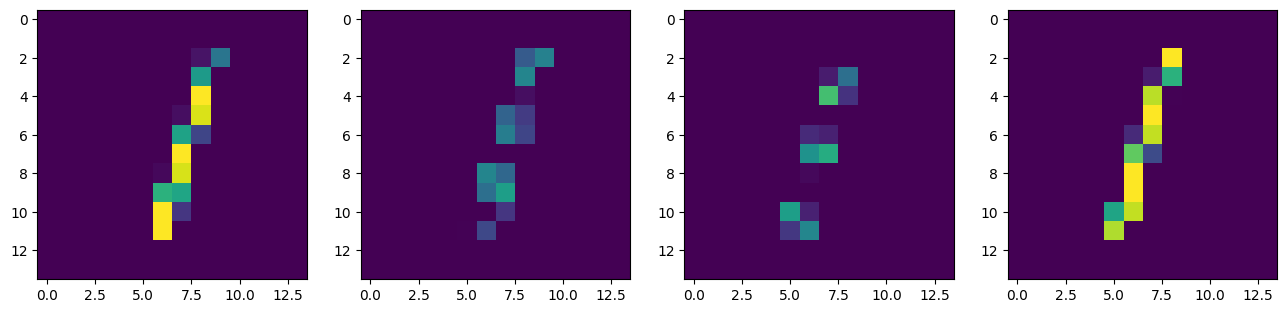

In [10]:
from matplotlib import pyplot as plt

print(test_layer.open([0,1,3,2]).shape)

post = test_layer.open([0,1,3,2])

_min, _max = np.amin(post), np.amax(post)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[c].imshow(post[2,:,:,c],vmin = _min, vmax = _max)

In [13]:
for variant  in permutations:

    label = ''.join(map(str,variant))
    # print(label)
    tr_images = train_layer.open(variant)
    te_images =  test_layer.open(variant)
    run(tr_images,te_images,label)

Epoch 1/60
469/469 - 3s - 5ms/step - accuracy: 0.8188 - loss: 0.6495 - val_accuracy: 0.9077 - val_loss: 0.3421
Epoch 2/60
469/469 - 2s - 4ms/step - accuracy: 0.9103 - loss: 0.3217 - val_accuracy: 0.9189 - val_loss: 0.2819
Epoch 3/60
469/469 - 2s - 3ms/step - accuracy: 0.9211 - loss: 0.2772 - val_accuracy: 0.9297 - val_loss: 0.2487
Epoch 4/60
469/469 - 2s - 3ms/step - accuracy: 0.9276 - loss: 0.2554 - val_accuracy: 0.9286 - val_loss: 0.2437
Epoch 5/60
469/469 - 2s - 4ms/step - accuracy: 0.9310 - loss: 0.2428 - val_accuracy: 0.9305 - val_loss: 0.2359
Epoch 6/60
469/469 - 2s - 4ms/step - accuracy: 0.9324 - loss: 0.2352 - val_accuracy: 0.9270 - val_loss: 0.2469
Epoch 7/60
469/469 - 2s - 3ms/step - accuracy: 0.9341 - loss: 0.2287 - val_accuracy: 0.9337 - val_loss: 0.2264
Epoch 8/60
469/469 - 2s - 4ms/step - accuracy: 0.9356 - loss: 0.2225 - val_accuracy: 0.9311 - val_loss: 0.2281
Epoch 9/60
469/469 - 2s - 4ms/step - accuracy: 0.9371 - loss: 0.2181 - val_accuracy: 0.9360 - val_loss: 0.2241
E

In [11]:
variantes_diagonal = permutations[1] #select only the diagonal permutation 

In [19]:
diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]


In [41]:
import pandas as pd

# Initialize accuracy lists
diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

# Iterate over permutations
for ind, variant in enumerate(permutations):
    label = ''.join(map(str, variant))
    file = train_layer.name + "/" + label
    
    try:
        # Read the CSV file
        df = pd.read_csv(file)
        
        # Extract the last 30 validation accuracy values
        val_accuracy_values = df['val_accuracy'].tail(30).tolist()
        
        # Append to the appropriate group based on index
        if ind in diagonal_index:
            diagonal_val_accuracy.append(val_accuracy_values)
        elif ind in vertical_index:
            vertical_val_accuracy.append(val_accuracy_values)
        elif ind in horizontal_index:
            horizontal_val_accuracy.append(val_accuracy_values)
    
    except FileNotFoundError:
        print(f"File not found: {file}")
    except pd.errors.EmptyDataError:
        print(f"Empty or invalid data in file: {file}")


In [42]:
from itertools import chain

# Flatten diagonal_val_accuracy
diagonal_val_accuracy_flattened = list(chain.from_iterable(diagonal_val_accuracy))

# Flatten vertical_val_accuracy
vertical_val_accuracy_flattened = list(chain.from_iterable(vertical_val_accuracy))

# Flatten horizontal_val_accuracy
horizontal_val_accuracy_flattened = list(chain.from_iterable(horizontal_val_accuracy))


In [43]:
no_fitler_val_accuracy = []

for ind, variant in enumerate(permutations):
    label = ''.join(map(str, variant))
    file = train_layer.name + "/" + label
    
    try:
        # Read the CSV file
        df = pd.read_csv(file)
        
        # Extract the last 30 validation accuracy values
        no_fitler_val_accuracy.extend(df['val_accuracy'].tail(30).tolist())
        
    except FileNotFoundError:
        print(f"File not found: {file}")
    except pd.errors.EmptyDataError:
        print(f"Empty or invalid data in file: {file}")

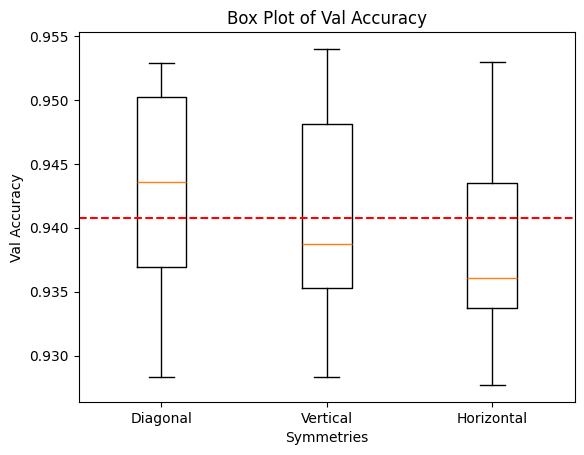

In [44]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')


# Add title and labels
plt.title('Box Plot of Val Accuracy')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()